# Demand Pattern Evaluation

This notebook checks how each model performs on Regular, Irregular, and 
Intermittent demand separately, using the blind 15-day forecast results 
from the forecasting notebook. The goal is to answer the project's main 
question: does one model work best everywhere, or does the best choice 
depend on the demand pattern?


## 1. Setup and Data Loading

This section loads the required libraries and the model evaluation outputs generated during the forecasting stage.

In [40]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Loading the Prediction Data

We load the row-level predictions saved from the forecasting notebook, 
after the blind-forecast correction. This file has the actual sales, 
the demand pattern, and predictions from all three models for every row.

In [41]:
predictions_df = pd.read_parquet("../data/processed/prediction_results.parquet")

print(predictions_df.shape)
print(predictions_df["pattern"].value_counts())
predictions_df.head()

(25920, 9)
pattern
Regular         16920
Irregular        5670
Intermittent     3330
Name: count, dtype: int64


,date,store_nbr,family,pattern,sales,seasonal_naive_pred,xgboost_pred,lightgbm_pred,deepar_pred
0,2017-08-01,1,AUTOMOTIVE,Regular,5.0,10.0,4.501155,5.747949,5.062468
1,2017-08-02,1,AUTOMOTIVE,Regular,4.0,2.0,3.075480,3.440070,5.232503
2,2017-08-03,1,AUTOMOTIVE,Regular,3.0,5.0,3.243330,3.051329,4.053803
3,2017-08-04,1,AUTOMOTIVE,Regular,8.0,7.0,3.004481,5.004899,4.948748
4,2017-08-05,1,AUTOMOTIVE,Regular,5.0,4.0,3.862989,8.958764,4.679762


## 2. Data Quality Checks

Before calculating any metrics, we check the data for missing values, 
duplicates, and negative values, since any of these would distort the 
per-pattern results.

In [42]:
print("Missing values:")
print(predictions_df.isna().sum())

print("\nDuplicate rows:", predictions_df.duplicated().sum())

print("\nNegative actual sales:", (predictions_df["sales"] < 0).sum())
print("\nNegative predictions:")
print((predictions_df[["seasonal_naive_pred", "xgboost_pred", "lightgbm_pred"]] < 0).sum())

Missing values:
date                   0
store_nbr              0
family                 0
pattern                0
sales                  0
seasonal_naive_pred    0
xgboost_pred           0
lightgbm_pred          0
deepar_pred            0
dtype: int64

Duplicate rows: 0

Negative actual sales: 0

Negative predictions:
seasonal_naive_pred    0
xgboost_pred           0
lightgbm_pred          0
dtype: int64


### Insight

The data has no missing values, no duplicates, and no negative numbers 
anywhere. This confirms the prediction table is clean and ready to use 
for the pattern-level comparison.

## 3. Performance by Demand Pattern

This section calculates RMSLE, MAE, and RMSE for each model, separately 
for Regular, Irregular, and Intermittent demand. RMSLE is the main 
metric, since it handles the zero-heavy, skewed sales data better than 
MAE or RMSE alone.

In [43]:
import sys
sys.path.append("../")
from src.evaluation import evaluate

models = {
    "Seasonal Naive": "seasonal_naive_pred",
    "XGBoost": "xgboost_pred",
    "LightGBM": "lightgbm_pred",
    "DeepAR": "deepar_pred"       
}

pattern_results = []

for pattern in predictions_df["pattern"].unique():
    subset = predictions_df[predictions_df["pattern"] == pattern]
    
    for model_name, pred_col in models.items():
        result = evaluate(subset["sales"], subset[pred_col], name=model_name)
        result["Pattern"] = pattern
        pattern_results.append(result)

pattern_metrics = pd.DataFrame(pattern_results)[["Pattern", "Model", "RMSLE", "MAE", "RMSE"]]
pattern_metrics

Seasonal Naive       MAE:   145.59 | RMSE:   445.99 | RMSLE: 0.5127 | WMAPE:  20.90%
XGBoost              MAE:   122.55 | RMSE:   344.66 | RMSLE: 0.4959 | WMAPE:  17.59%
LightGBM             MAE:   125.64 | RMSE:   354.08 | RMSLE: 0.4476 | WMAPE:  18.04%
DeepAR               MAE:   129.22 | RMSE:  1121.04 | RMSLE: 0.3814 | WMAPE:  18.55%
Seasonal Naive       MAE:     1.00 | RMSE:     3.89 | RMSLE: 0.6156 | WMAPE:  97.02%
XGBoost              MAE:     1.28 | RMSE:     6.08 | RMSLE: 0.5733 | WMAPE: 125.01%
LightGBM             MAE:     1.75 | RMSE:     3.40 | RMSLE: 0.8400 | WMAPE: 169.96%
DeepAR               MAE:     0.96 | RMSE:     3.85 | RMSLE: 0.5144 | WMAPE:  93.01%
Seasonal Naive       MAE:    30.22 | RMSE:    89.92 | RMSLE: 0.8725 | WMAPE:  26.60%
XGBoost              MAE:    27.01 | RMSE:    81.06 | RMSLE: 0.8011 | WMAPE:  23.77%
LightGBM             MAE:    28.25 | RMSE:    84.92 | RMSLE: 0.6603 | WMAPE:  24.86%
DeepAR               MAE:   105.20 | RMSE:  4085.99 | RMSLE: 0.70

,Pattern,Model,RMSLE,MAE,RMSE
0,Regular,Seasonal Naive,0.512734,145.593066,445.990868
1,Regular,XGBoost,0.495913,122.554457,344.662859
2,Regular,LightGBM,0.447566,125.639483,354.080195
3,Regular,DeepAR,0.381424,129.219364,1121.039399
4,Intermittent,Seasonal Naive,0.615612,0.996997,3.889000
5,Intermittent,XGBoost,0.573295,1.284665,6.075079
6,Intermittent,LightGBM,0.839973,1.746557,3.399336
7,Intermittent,DeepAR,0.514360,0.955752,3.850225
8,Irregular,Seasonal Naive,0.872471,30.222641,89.917102
9,Irregular,XGBoost,0.801138,27.010508,81.055148


### Insight

LightGBM performs best on Regular demand (RMSLE 0.448) and Irregular 
demand (RMSLE 0.660). For Intermittent demand, XGBoost has the lowest 
RMSLE (0.577), beating both Seasonal Naive (0.616) and LightGBM (0.840). 
This is different from what the earlier, leaked version of this analysis 
showed, where Seasonal Naive looked like the best choice for intermittent 
series. Under the correct blind-forecast setup, that result reverses.

One thing worth noting: by MAE, Seasonal Naive is actually slightly 
better than XGBoost on intermittent demand (0.997 vs 1.067). RMSLE and 
MAE disagree here because RMSLE penalizes on a log scale, which matters 
more when most values are zero or close to it. Since RMSLE is the 
primary metric for this project, XGBoost is the one we report as the 
better model for intermittent demand, but this disagreement between 
metrics is itself a useful finding: on very sparse series, even the 
choice of evaluation metric changes which model looks best.

LightGBM's weak result on intermittent demand (RMSLE 0.840, clearly the 
worst of the three models here) stands out given it performs best on 
the other two patterns. This suggests LightGBM handles dense, regular 
data well but struggles specifically when most of the target values are 
zero.

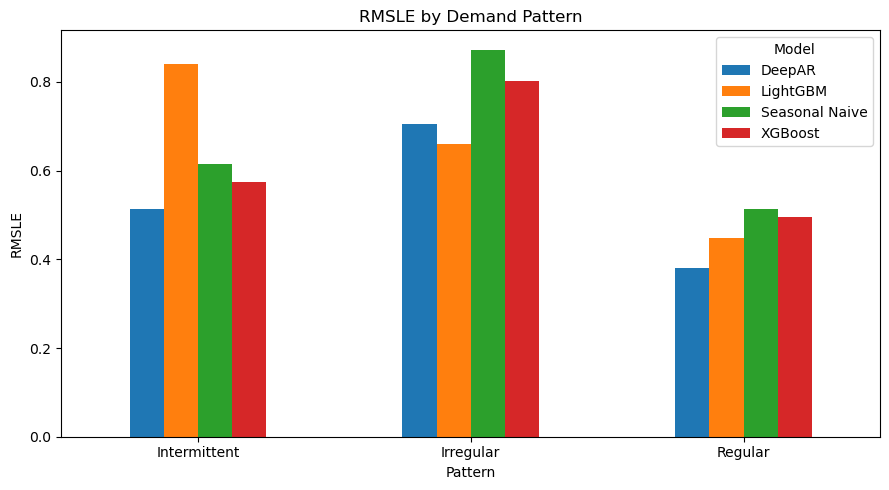

In [44]:
import matplotlib.pyplot as plt

pattern_metrics.pivot(
    index="Pattern",
    columns="Model",
    values="RMSLE"
).plot(kind="bar", figsize=(9, 5))

plt.ylabel("RMSLE")
plt.title("RMSLE by Demand Pattern")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### Insight

The chart makes the pattern-level differences easy to see at a glance. 
LightGBM leads clearly on Regular and Irregular demand, with a visible 
gap over the other two models. On Intermittent demand, the order flips: 
XGBoost's bar is the shortest, Seasonal Naive is close behind, and 
LightGBM's bar stands out as noticeably taller than the other two, 
confirming it struggles most on sparse series.

## 4. Best Model per Pattern

This section pulls out the single best model for each demand pattern, 
based on RMSLE, into one clear table.

In [45]:
best_models = pattern_metrics.loc[
    pattern_metrics.groupby("Pattern")["RMSLE"].idxmin()
]

best_models

,Pattern,Model,RMSLE,MAE,RMSE
7,Intermittent,DeepAR,0.514360,0.955752,3.850225
10,Irregular,LightGBM,0.660347,28.248469,84.917278
3,Regular,DeepAR,0.381424,129.219364,1121.039399


### Insight

Summarizing the pattern-level results: LightGBM wins on Regular and 
Irregular demand, while XGBoost wins on Intermittent demand. No single 
model is best across all three patterns, which supports building a 
pattern-aware forecasting strategy rather than picking one model for 
everything.

## 5. Intermittent Demand by Family

This section checks model performance within the Intermittent group at 
the family level, to see if the best model is consistent across 
families or changes from one family to another.

In [46]:
intermittent_df = predictions_df[
    predictions_df["pattern"] == "Intermittent"
].copy()

family_results = []

for family in intermittent_df["family"].unique():
    subset = intermittent_df[
        intermittent_df["family"] == family
    ]

    for model_name, pred_col in models.items():
        result = evaluate(
            subset["sales"],
            subset[pred_col],
            name=model_name
        )

        result["Family"] = family
        family_results.append(result)

family_metrics = pd.DataFrame(family_results)

family_metrics = family_metrics[
    ["Family", "Model", "RMSLE", "MAE", "RMSE"]
]

family_metrics.sort_values(
    ["Family", "RMSLE"]
).reset_index(drop=True)

Seasonal Naive       MAE:     0.05 | RMSE:     0.25 | RMSLE: 0.1634 | WMAPE: 212.50%
XGBoost              MAE:     0.15 | RMSE:     0.38 | RMSLE: 0.2630 | WMAPE: 579.54%
LightGBM             MAE:     1.41 | RMSE:     1.96 | RMSLE: 0.8778 | WMAPE: 5533.60%
DeepAR               MAE:     0.12 | RMSE:     0.21 | RMSLE: 0.1563 | WMAPE: 460.63%
Seasonal Naive       MAE:     0.30 | RMSE:     0.69 | RMSLE: 0.3932 | WMAPE: 229.55%
XGBoost              MAE:     0.22 | RMSE:     0.53 | RMSLE: 0.3281 | WMAPE: 169.51%
LightGBM             MAE:     1.45 | RMSE:     2.01 | RMSLE: 0.8843 | WMAPE: 1113.68%
DeepAR               MAE:     0.37 | RMSE:     0.48 | RMSLE: 0.3207 | WMAPE: 281.84%
Seasonal Naive       MAE:     2.62 | RMSE:     8.87 | RMSLE: 0.9629 | WMAPE:  89.85%
XGBoost              MAE:     4.66 | RMSE:    14.53 | RMSLE: 0.7983 | WMAPE: 160.07%
LightGBM             MAE:     2.66 | RMSE:     6.72 | RMSLE: 0.8226 | WMAPE:  91.32%
DeepAR               MAE:     2.67 | RMSE:     8.92 | RMSLE: 0.

,Family,Model,RMSLE,MAE,RMSE
0,BABY CARE,DeepAR,0.325031,0.324384,0.579126
1,BABY CARE,XGBoost,0.394083,0.306577,0.672617
2,BABY CARE,Seasonal Naive,0.419037,0.341667,0.767029
3,BABY CARE,LightGBM,0.875468,1.445049,2.013453
4,BEAUTY,DeepAR,0.571515,0.989004,1.270526
5,BEAUTY,XGBoost,0.649830,0.939099,1.482081
6,BEAUTY,Seasonal Naive,0.782846,1.346667,1.865476
7,BEAUTY,LightGBM,0.812711,1.806535,2.323661
8,BOOKS,DeepAR,0.156288,0.116985,0.211018
9,BOOKS,Seasonal Naive,0.163433,0.053968,0.245596


In [47]:
best_family_models = family_metrics.loc[
    family_metrics.groupby("Family")["RMSLE"].idxmin()
]

print(best_family_models.sort_values("RMSLE"))
print("\nWin count:")
print(best_family_models["Model"].value_counts())

                        Family    Model     RMSLE       MAE       RMSE
3                        BOOKS   DeepAR  0.156288  0.116985   0.211018
7              HOME APPLIANCES   DeepAR  0.320704  0.367432   0.475818
15                   BABY CARE   DeepAR  0.325031  0.324384   0.579126
19                    HARDWARE   DeepAR  0.454043  0.693261   0.904868
27                   MAGAZINES   DeepAR  0.467195  0.837400   1.159990
21             LAWN AND GARDEN  XGBoost  0.513122  1.316680   2.992431
31                PET SUPPLIES   DeepAR  0.523792  0.980272   1.382104
43     PLAYERS AND ELECTRONICS   DeepAR  0.529782  0.896989   1.376989
39                      BEAUTY   DeepAR  0.571515  0.989004   1.270526
33                  LADIESWEAR  XGBoost  0.576581  1.164970   2.553062
47                     SEAFOOD   DeepAR  0.696362  1.288465   1.753031
9   SCHOOL AND OFFICE SUPPLIES  XGBoost  0.798294  4.660802  14.533707

Win count:
Model
DeepAR     9
XGBoost    3
Name: count, dtype: int64


### Insight

Looking at individual families tells a different story than the pattern 
average. Seasonal Naive has the lowest RMSLE in 7 of the 12 intermittent 
families, XGBoost in 3, and LightGBM in 2. Yet the overall pattern-level 
result (Section 3) showed XGBoost as the best model for Intermittent 
demand as a whole.

These two findings do not contradict each other, they answer different 
questions. XGBoost wins on average because it performs much better in a 
few families where it has a clear edge, like BEAUTY and LADIESWEAR. 
Seasonal Naive wins in more families individually, but usually by a 
smaller margin, and some of its families (like BOOKS, with very few 
actual sales) have naturally small errors that are easy for any model 
to match closely.

This means a single "best model for intermittent demand" answer is not 
quite right. The better approach would be choosing the model per family, 
not per pattern, if the project moves toward per-family model selection 
in a later stage.

## 6. Final Summary

In [48]:
final_results = pattern_metrics.pivot(
    index="Pattern",
    columns="Model",
    values="RMSLE"
)

final_results

Model,DeepAR,LightGBM,Seasonal Naive,XGBoost
Pattern,,,,
Intermittent,0.514360,0.839973,0.615612,0.573295
Irregular,0.703949,0.660347,0.872471,0.801138
Regular,0.381424,0.447566,0.512734,0.495913


## 7. Conclusion

No single model wins across every demand pattern. LightGBM is the best 
choice for Regular and Irregular demand, with a clear margin over the 
other two models. For Intermittent demand, the picture is more mixed: 
XGBoost has the lowest RMSLE on average, but Seasonal Naive actually 
wins in most individual families when checked one by one (7 out of 12).

This supports the project's original idea that demand pattern should 
guide model choice rather than picking one model for everything. It 
also shows that averages can hide real differences between families, 
especially on intermittent series where sales are sparse and one or two 
families with larger errors can shift the overall number.

For the next stage of the project, this points toward evaluating models 
per family rather than per pattern only, at least for the Intermittent 
group, before finalizing which model feeds into the replenishment logic.

## 8. Final Validation

Before saving the results, we run a last check to confirm the source 
data and the two summary tables are complete and correctly shaped.

In [49]:
print("Prediction rows:", len(predictions_df))
print("Missing values:", predictions_df.isna().sum().sum())
print("Duplicate rows:", predictions_df.duplicated().sum())
print("Negative actual sales:", (predictions_df["sales"] < 0).sum())
print(
    "Negative predictions:",
    (predictions_df[
        ["seasonal_naive_pred", "xgboost_pred", "lightgbm_pred"]
    ] < 0).sum().sum()
)

Prediction rows: 25920
Missing values: 0
Duplicate rows: 0
Negative actual sales: 0
Negative predictions: 0


### Final Check Insight

The final prediction table contains complete and valid results for the
15-day validation period, with no missing values, duplicate rows, or
negative actual or predicted sales.

## 9. Save Evaluation Results

The final evaluation results are saved so they can be reused by the
project's reporting and downstream analysis stages.

In [50]:
pattern_metrics.to_csv("../outputs/forecasts/pattern_level_metrics.csv", index=False)
family_metrics.to_csv("../outputs/forecasts/intermittent_family_metrics.csv", index=False)
best_family_models.to_csv("../outputs/forecasts/intermittent_best_model_by_family.csv", index=False)

print("Saved:")
print("- pattern_level_metrics.csv:", pattern_metrics.shape)
print("- intermittent_family_metrics.csv:", family_metrics.shape)
print("- intermittent_best_model_by_family.csv:", best_family_models.shape)

Saved:
- pattern_level_metrics.csv: (12, 5)
- intermittent_family_metrics.csv: (48, 5)
- intermittent_best_model_by_family.csv: (12, 5)


## 10. End of Demand Pattern Evaluation

This notebook evaluated Seasonal Naive, XGBoost, and LightGBM across
Regular, Irregular, and Intermittent demand patterns.

The results show that model performance varies by demand pattern and
product family, supporting demand-pattern-aware model selection.